In [ ]:
!pip install -q catboost==1.2.7 lightgbm==4.5.0 optuna==4.0.0 shap==0.46.0 xgboost==2.1.1


In [ ]:
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.isotonic import IsotonicRegression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    average_precision_score,
    brier_score_loss,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    roc_auc_score,
    roc_curve,
)
from sklearn.calibration import calibration_curve
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from catboost import CatBoostClassifier
import lightgbm as lgb
import xgboost as xgb
import shap

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 110


In [ ]:
def add_derived_features(df):
    df = df.copy()
    df['total_prior_visits'] = df['n_inpatient'] + df['n_outpatient'] + df['n_emergency']
    df['emergency_ratio'] = df['n_emergency'] / (df['total_prior_visits'] + 1)
    df['meds_per_day'] = df['n_medications'] / (df['time_in_hospital'] + 1)
    df['procedures_per_day'] = df['n_procedures'] / (df['time_in_hospital'] + 1)
    df['labs_per_day'] = df['n_lab_procedures'] / (df['time_in_hospital'] + 1)
    df['had_emergency_visit'] = (df['n_emergency'] > 0).astype(int)
    df['frequent_inpatient'] = (df['n_inpatient'] >= 2).astype(int)
    diag_cols = [c for c in ('diag_1', 'diag_2', 'diag_3') if c in df.columns]
    if diag_cols:
        df['n_distinct_diagnoses'] = (df[diag_cols].astype(str).ne('Missing')).sum(axis=1).astype(int)
    else:
        df['n_distinct_diagnoses'] = 0
    a1c = df['A1Ctest'].astype(str).str.lower() if 'A1Ctest' in df.columns else None
    dmed = df['diabetes_med'].astype(str).str.lower() if 'diabetes_med' in df.columns else None
    if a1c is not None and dmed is not None:
        df['poorly_controlled_diabetes'] = (a1c.eq('high') & dmed.eq('yes')).astype(int)
    else:
        df['poorly_controlled_diabetes'] = 0
    return df


def compute_metrics(y_true, y_proba, threshold=0.5):
    y_pred = (y_proba >= threshold).astype(int)
    return {
        'roc_auc': float(roc_auc_score(y_true, y_proba)),
        'pr_auc': float(average_precision_score(y_true, y_proba)),
        'f1': float(f1_score(y_true, y_pred)),
        'brier': float(brier_score_loss(y_true, y_proba)),
    }


def find_optimal_threshold(y_true, y_proba):
    thresholds = np.linspace(0.1, 0.9, 81)
    scores = [f1_score(y_true, (y_proba >= t).astype(int)) for t in thresholds]
    best_idx = int(np.argmax(scores))
    return float(thresholds[best_idx]), float(scores[best_idx])


def plot_roc_pr_side_by_side(results_dict, title=''):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
    axes[0].plot([0, 1], [0, 1], linestyle='--', color='grey')
    base_rate = None
    for name, (y_true, y_proba) in results_dict.items():
        fpr, tpr, _ = roc_curve(y_true, y_proba)
        auc = roc_auc_score(y_true, y_proba)
        axes[0].plot(fpr, tpr, label=f'{name} (AUC = {auc:.3f})')
        prec, rec, _ = precision_recall_curve(y_true, y_proba)
        ap = average_precision_score(y_true, y_proba)
        axes[1].plot(rec, prec, label=f'{name} (AP = {ap:.3f})')
        if base_rate is None:
            base_rate = float(np.mean(y_true))
    axes[0].set_xlabel('False positive rate'); axes[0].set_ylabel('True positive rate')
    axes[0].set_title('ROC'); axes[0].legend(loc='lower right')
    axes[1].hlines(base_rate, 0, 1, linestyles='--', colors='grey')
    axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
    axes[1].set_title('Precision-Recall'); axes[1].legend(loc='lower left')
    fig.suptitle(title)
    fig.tight_layout()
    plt.show()


def plot_calibration(y_true, y_proba_before, y_proba_after, title=''):
    fig, ax = plt.subplots(figsize=(6, 5))
    ax.plot([0, 1], [0, 1], linestyle='--', color='grey', label='Идеальная калибровка')
    for proba, label in [(y_proba_before, 'До калибровки'), (y_proba_after, 'После isotonic')]:
        frac_pos, mean_pred = calibration_curve(y_true, proba, n_bins=10, strategy='quantile')
        brier = brier_score_loss(y_true, proba)
        ax.plot(mean_pred, frac_pos, marker='o', label=f'{label} (Brier = {brier:.4f})')
    ax.set_xlabel('Средняя предсказанная вероятность')
    ax.set_ylabel('Доля положительного класса')
    ax.set_title(title or 'Reliability diagram')
    ax.legend(loc='upper left')
    ax.grid(alpha=0.3)
    plt.show()


def plot_confusion(y_true, y_proba, threshold=0.5, title=''):
    y_pred = (y_proba >= threshold).astype(int)
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(4.5, 4.5))
    ConfusionMatrixDisplay(cm, display_labels=['не реадмит.', 'реадмит.']).plot(
        ax=ax, values_format='d', colorbar=False,
    )
    ax.set_title(title or f'Confusion matrix @ thr={threshold:.2f}')
    plt.show()


### Загрузка данных



In [ ]:
df = None
try:
    from google.colab import files
    uploaded = files.upload()
    csv_name = next(iter(uploaded))
    df = pd.read_csv(csv_name)
except Exception:
    for candidate in ('data/raw/hospital_readmissions.csv',
                      '../data/raw/hospital_readmissions.csv',
                      'hospital_readmissions.csv'):
        if Path(candidate).exists():
            df = pd.read_csv(candidate)
            break
if df is None:
    raise FileNotFoundError('Поместите файл hospital_readmissions.csv рядом с ноутбуком или в data/raw/.')
print(f'Форма выборки: {df.shape[0]} строк, {df.shape[1]} колонок')
df.head()


## Анализ




### Распределение целевого класса


In [ ]:
target_binary = (df['readmitted'].astype(str).str.lower() == 'yes').astype(int)
pos_rate = target_binary.mean()
fig, ax = plt.subplots(figsize=(5, 4))
counts = target_binary.value_counts().sort_index()
sns.barplot(x=['no', 'yes'], y=counts.values, ax=ax, color='steelblue')
ax.set_title(f'Баланс классов (positive rate = {pos_rate:.3f})')
ax.set_xlabel('readmitted'); ax.set_ylabel('Количество пациентов')
plt.show()


### Распределения числовых признаков


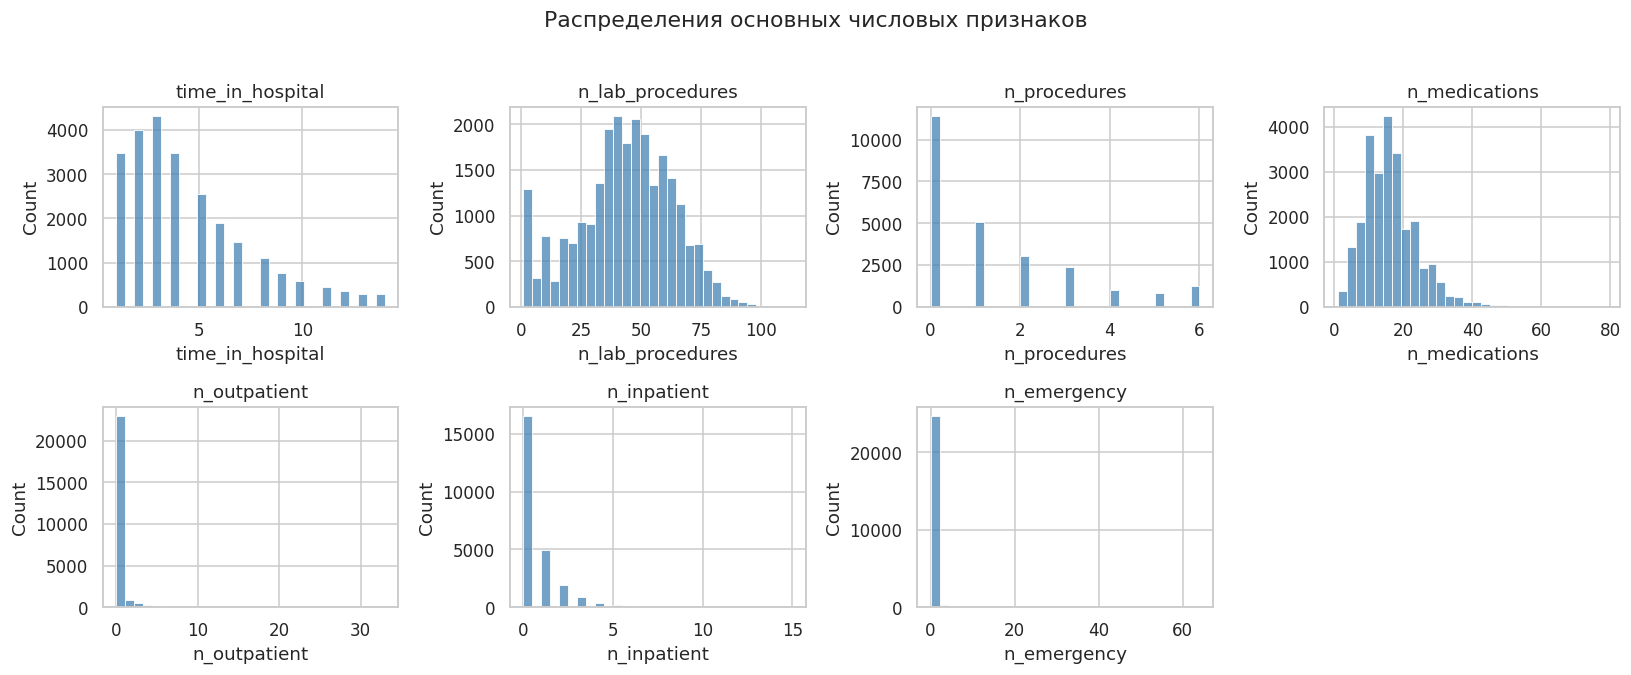

In [6]:
numeric_base = ['time_in_hospital', 'n_lab_procedures', 'n_procedures',
                'n_medications', 'n_outpatient', 'n_inpatient', 'n_emergency']
fig, axes = plt.subplots(2, 4, figsize=(15, 6))
axes = axes.ravel()
for ax, col in zip(axes, numeric_base):
    sns.histplot(df[col], bins=30, ax=ax, color='steelblue')
    ax.set_title(col)
axes[-1].axis('off')
fig.suptitle('Распределения основных числовых признаков', y=1.02)
fig.tight_layout()
plt.show()


### Частота реадмиссий по возрастным группам


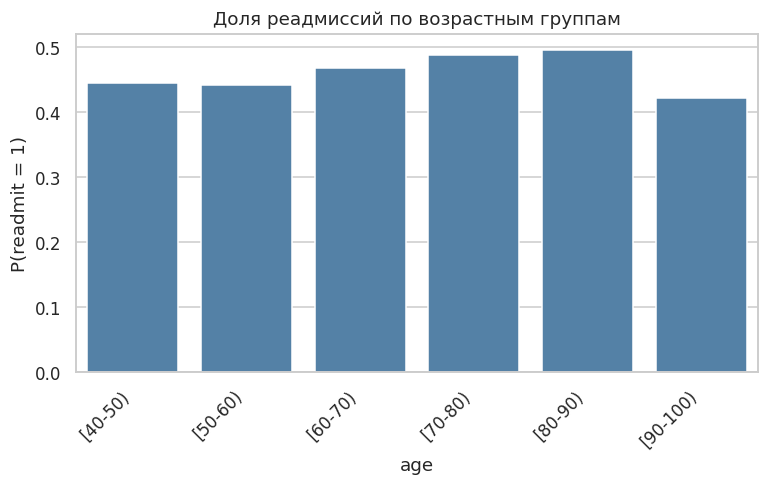

In [7]:
age_rate = df.assign(y=target_binary).groupby('age')['y'].mean().sort_index()
fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(x=age_rate.index.astype(str), y=age_rate.values, ax=ax, color='steelblue')
ax.set_title('Доля реадмиссий по возрастным группам')
ax.set_xlabel('age'); ax.set_ylabel('P(readmit = 1)')
plt.setp(ax.get_xticklabels(), rotation=45, ha='right')
plt.show()


### Число прошлых стационарных визитов и таргет


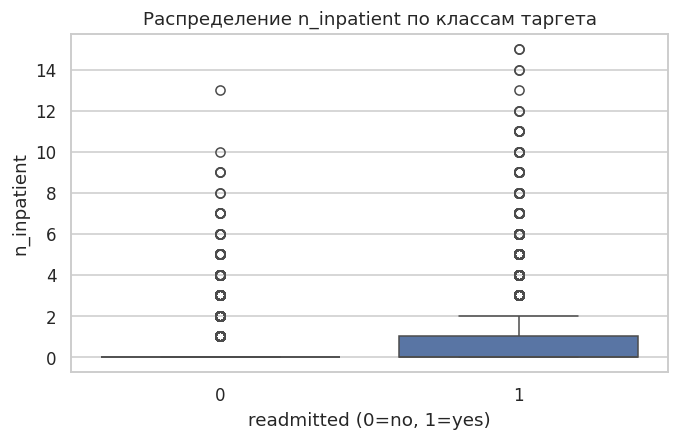

In [8]:
fig, ax = plt.subplots(figsize=(7, 4))
sns.boxplot(data=df.assign(y=target_binary), x='y', y='n_inpatient', ax=ax)
ax.set_title('Распределение n_inpatient по классам таргета')
ax.set_xlabel('readmitted (0=no, 1=yes)')
plt.show()


### Корреляционная матрица числовых признаков


In [ ]:
corr = df[numeric_base].assign(y=target_binary).corr()
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax)
ax.set_title('Корреляции числовых признаков и таргета')
fig.tight_layout()
plt.show()


## Препроцессинг и конструирование признаков



In [ ]:
y = (df['readmitted'].astype(str).str.lower() == 'yes').astype(int)
X = df.drop(columns=['readmitted'])
X = add_derived_features(X)
print(f'Итоговое число признаков: {X.shape[1]} (исходных 16 плюс 9 производных)')


### Производные признаки и их клиническое обоснование

| Признак | Определение | Клиническое обоснование |
|---|---|---|
| `total_prior_visits` | `n_inpatient + n_outpatient + n_emergency` | Суммарная история контактов со здравоохранением как устойчивый маркер общей медикализированности пациента |
| `emergency_ratio` | `n_emergency / (total_prior_visits + 1)` | Доля экстренных визитов среди всех обращений, показатель нестабильного течения заболевания |
| `meds_per_day` | `n_medications / (time_in_hospital + 1)` | Интенсивность лекарственной терапии на день стационара, прокси тяжести состояния |
| `procedures_per_day` | `n_procedures / (time_in_hospital + 1)` | Интенсивность процедур на день стационара |
| `labs_per_day` | `n_lab_procedures / (time_in_hospital + 1)` | Интенсивность лабораторных тестов на день стационара |
| `had_emergency_visit` | `n_emergency > 0` | Бинарный флаг наличия хотя бы одного экстренного визита, линейно интерпретируемый признак |
| `frequent_inpatient` | `n_inpatient >= 2` | Два и более прошлых стационара известно как сильный предиктор реадмиссии (Kansagara et al. 2011) |
| `n_distinct_diagnoses` | Количество непропущенных значений среди `diag_1`..`diag_3` | Число диагнозов как мера коморбидности и сложности ведения пациента |
| `poorly_controlled_diabetes` | `A1Ctest == 'high' AND diabetes_med == 'yes'` | Высокий A1C на фоне назначенной терапии, канонический HEDIS-маркер плохо контролируемого диабета |


In [11]:
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.15, stratify=y, random_state=RANDOM_STATE,
)
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.15, stratify=y_trainval, random_state=RANDOM_STATE,
)
# Финальное дообучение использует конкатенацию train+val в порядке
# [X_train, X_val], что воспроизводит протокол основного репозитория.
X_trainval_concat = pd.concat([X_train, X_val], ignore_index=True)
y_trainval_concat = pd.concat([y_train, y_val], ignore_index=True)
for name, ys in (('train', y_train), ('val', y_val), ('test', y_test)):
    print(f'{name}: n={len(ys)}, positive_rate={ys.mean():.4f}')


train: n=18062, positive_rate=0.4702
val: n=3188, positive_rate=0.4702
test: n=3750, positive_rate=0.4701


## Логистическая регрессия как нижняя граница


In [ ]:
numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = [c for c in X.columns if c not in numeric_cols]

baseline_pipeline = Pipeline([
    ('preprocess', ColumnTransformer([
        ('num', Pipeline([
            ('impute', SimpleImputer(strategy='median')),
            ('scale', StandardScaler()),
        ]), numeric_cols),
        ('cat', Pipeline([
            ('impute', SimpleImputer(strategy='most_frequent')),
            ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
        ]), categorical_cols),
    ])),
    ('model', LogisticRegression(class_weight='balanced', max_iter=1000, random_state=RANDOM_STATE)),
])
baseline_pipeline.fit(X_train, y_train)
y_proba_base_val = baseline_pipeline.predict_proba(X_val)[:, 1]
y_proba_base_test = baseline_pipeline.predict_proba(X_test)[:, 1]
m_base_val = compute_metrics(y_val, y_proba_base_val)
m_base_test = compute_metrics(y_test, y_proba_base_test)
print('Baseline val:', {k: f'{v:.4f}' for k, v in m_base_val.items()})
print('Baseline test:', {k: f'{v:.4f}' for k, v in m_base_test.items()})
plot_roc_pr_side_by_side({'baseline': (y_val, y_proba_base_val)}, 'LogisticRegression на val')
plot_confusion(y_val, y_proba_base_val, title='Baseline @ thr=0.5')


## RandomForest как нелинейный бейзлайн




In [ ]:
rf_pipeline = Pipeline([
    ('preprocess', ColumnTransformer([
        ('num', SimpleImputer(strategy='median'), numeric_cols),
        ('cat', Pipeline([
            ('impute', SimpleImputer(strategy='most_frequent')),
            ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
        ]), categorical_cols),
    ])),
    ('model', RandomForestClassifier(n_estimators=500, class_weight='balanced',
                                     n_jobs=-1, random_state=RANDOM_STATE)),
])
rf_pipeline.fit(X_train, y_train)
y_proba_rf_val = rf_pipeline.predict_proba(X_val)[:, 1]
y_proba_rf_test = rf_pipeline.predict_proba(X_test)[:, 1]
m_rf_val = compute_metrics(y_val, y_proba_rf_val)
m_rf_test = compute_metrics(y_test, y_proba_rf_test)
print('RF val:', {k: f'{v:.4f}' for k, v in m_rf_val.items()})
print('RF test:', {k: f'{v:.4f}' for k, v in m_rf_test.items()})


## CatBoost как основная модель




### Замечание о гиперпараметрическом поиске



In [ ]:
catboost_best_params = {
    'iterations': 599,
    'learning_rate': 0.07928165803332184,
    'depth': 8,
    'l2_leaf_reg': 2.434043184566189,
    'random_strength': 2.9920167318206436,
    'border_count': 47,
    'min_data_in_leaf': 63,
    'grow_policy': 'SymmetricTree',
    'one_hot_max_size': 4,
    'bagging_temperature': 0.6531073597438415,
}

def prepare_for_catboost(df_in):
    df_out = df_in.copy()
    for col in categorical_cols:
        df_out[col] = df_out[col].astype(object).where(df_out[col].notna(), 'missing').astype(str)
    return df_out

X_train_cb = prepare_for_catboost(X_train)
X_val_cb = prepare_for_catboost(X_val)
X_test_cb = prepare_for_catboost(X_test)
X_trainval_cb = prepare_for_catboost(X_trainval_concat)

cb_common = dict(
    loss_function='Logloss', eval_metric='AUC',
    auto_class_weights='Balanced',
    random_seed=RANDOM_STATE, verbose=False, allow_writing_files=False,
)

cb_honest = CatBoostClassifier(**catboost_best_params, **cb_common)
cb_honest.fit(
    X_train_cb, y_train, cat_features=categorical_cols,
    eval_set=(X_val_cb, y_val), early_stopping_rounds=50, use_best_model=True,
)
y_proba_cb_val = cb_honest.predict_proba(X_val_cb)[:, 1]
m_cb_val = compute_metrics(y_val, y_proba_cb_val)
honest_best_iter = cb_honest.tree_count_

scale = 1.0 + len(X_val) / max(len(X_train), 1)
iterations_cap = max(int(honest_best_iter * scale), 1)
cb_final_params = {**catboost_best_params, 'iterations': iterations_cap}
catboost_model = CatBoostClassifier(**cb_final_params, **cb_common)
catboost_model.fit(X_trainval_cb, y_trainval_concat, cat_features=categorical_cols)

y_proba_cb_test = catboost_model.predict_proba(X_test_cb)[:, 1]
m_cb_test = compute_metrics(y_test, y_proba_cb_test)
print(f'Honest val best_iter: {honest_best_iter}, refit iterations_cap: {iterations_cap}')
print('CatBoost val:', {k: f'{v:.4f}' for k, v in m_cb_val.items()})
print('CatBoost test:', {k: f'{v:.4f}' for k, v in m_cb_test.items()})
plot_roc_pr_side_by_side({'CatBoost': (y_val, y_proba_cb_val)}, 'CatBoost на honest val')


## LightGBM и XGBoost как независимые проверки



In [ ]:
lightgbm_best_params = {
    'learning_rate': 0.1043916618626319,
    'num_leaves': 81,
    'max_depth': 5,
    'min_data_in_leaf': 45,
    'feature_fraction': 0.6625898409046065,
    'bagging_fraction': 0.6550372155786113,
    'bagging_freq': 2,
    'lambda_l1': 0.27716289989683335,
    'lambda_l2': 1.0904877480384905,
}

def prepare_for_lgbm(df_in, categories=None):
    df_out = df_in.copy()
    cats_out = {}
    for col in categorical_cols:
        if categories and col in categories:
            df_out[col] = df_out[col].astype(str).astype(categories[col])
        else:
            cat = pd.CategoricalDtype(categories=sorted(df_out[col].astype(str).unique()))
            df_out[col] = df_out[col].astype(str).astype(cat)
            cats_out[col] = cat
    return df_out, cats_out

spw = float((y_train == 0).sum()) / max(float((y_train == 1).sum()), 1.0)
spw_full = float((y_trainval_concat == 0).sum()) / max(float((y_trainval_concat == 1).sum()), 1.0)
lgbm_common = dict(objective='binary', metric='auc', verbose=-1,
                   random_state=RANDOM_STATE)

# Шаг 1. Honest val.
X_tr_lgbm, lgbm_cats = prepare_for_lgbm(X_train)
X_va_lgbm, _ = prepare_for_lgbm(X_val, lgbm_cats)
X_te_lgbm, _ = prepare_for_lgbm(X_test, lgbm_cats)
lgbm_train_ds = lgb.Dataset(X_tr_lgbm, label=y_train,
                            categorical_feature=categorical_cols, free_raw_data=False)
lgbm_val_ds = lgb.Dataset(X_va_lgbm, label=y_val,
                          categorical_feature=categorical_cols,
                          reference=lgbm_train_ds, free_raw_data=False)
lgbm_honest = lgb.train({**lightgbm_best_params, **lgbm_common, 'scale_pos_weight': spw},
                        lgbm_train_ds, num_boost_round=1200, valid_sets=[lgbm_val_ds],
                        callbacks=[lgb.early_stopping(50, verbose=False),
                                   lgb.log_evaluation(period=0)])
y_proba_lgbm_val = lgbm_honest.predict(X_va_lgbm)
m_lgbm_val = compute_metrics(y_val, y_proba_lgbm_val)
best_iter_lgbm = int(lgbm_honest.best_iteration or lgbm_honest.current_iteration())

# Шаг 2. Refit на train+val в том же порядке строк, что и catboost.
X_trval_lgbm, lgbm_cats_full = prepare_for_lgbm(X_trainval_concat)
X_te_lgbm_refit, _ = prepare_for_lgbm(X_test, lgbm_cats_full)
lgbm_full_ds = lgb.Dataset(X_trval_lgbm, label=y_trainval_concat,
                           categorical_feature=categorical_cols, free_raw_data=False)
rounds_cap_lgbm = max(int(best_iter_lgbm * scale), 1)
lgbm_final = lgb.train({**lightgbm_best_params, **lgbm_common, 'scale_pos_weight': spw_full},
                       lgbm_full_ds, num_boost_round=rounds_cap_lgbm)
y_proba_lgbm_test = lgbm_final.predict(X_te_lgbm_refit)
m_lgbm_test = compute_metrics(y_test, y_proba_lgbm_test)
print(f'LightGBM honest best_iter: {best_iter_lgbm}, rounds_cap: {rounds_cap_lgbm}')
print('LightGBM val:', {k: f'{v:.4f}' for k, v in m_lgbm_val.items()})
print('LightGBM test:', {k: f'{v:.4f}' for k, v in m_lgbm_test.items()})


In [ ]:
xgboost_best_params = {
    'learning_rate': 0.14636485673684027,
    'max_depth': 4,
    'min_child_weight': 3.0502548335026147,
    'subsample': 0.6026268487517209,
    'colsample_bytree': 0.7767203627041872,
    'reg_alpha': 0.19000205902490747,
    'reg_lambda': 0.05350822875106499,
    'gamma': 3.263406001124904,
}

def prepare_for_xgb(df_in, categories=None):
    df_out = df_in.copy()
    cats_out = {}
    for col in categorical_cols:
        if categories and col in categories:
            df_out[col] = df_out[col].astype(str).astype(categories[col])
        else:
            cat = pd.CategoricalDtype(categories=sorted(df_out[col].astype(str).unique()))
            df_out[col] = df_out[col].astype(str).astype(cat)
            cats_out[col] = cat
    return df_out, cats_out

xgb_common = dict(objective='binary:logistic', eval_metric='auc',
                  tree_method='hist', random_state=RANDOM_STATE, verbosity=0)

X_tr_xgb, xgb_cats = prepare_for_xgb(X_train)
X_va_xgb, _ = prepare_for_xgb(X_val, xgb_cats)
X_te_xgb, _ = prepare_for_xgb(X_test, xgb_cats)
dtrain = xgb.DMatrix(X_tr_xgb, label=y_train, enable_categorical=True)
dval = xgb.DMatrix(X_va_xgb, label=y_val, enable_categorical=True)
dtest = xgb.DMatrix(X_te_xgb, label=y_test, enable_categorical=True)
xgb_honest = xgb.train({**xgboost_best_params, **xgb_common, 'scale_pos_weight': spw},
                       dtrain, num_boost_round=1200,
                       evals=[(dval, 'val')], early_stopping_rounds=50, verbose_eval=False)
y_proba_xgb_val = xgb_honest.predict(dval, iteration_range=(0, xgb_honest.best_iteration + 1))
m_xgb_val = compute_metrics(y_val, y_proba_xgb_val)
best_iter_xgb = int(xgb_honest.best_iteration)

X_trval_xgb, xgb_cats_full = prepare_for_xgb(X_trainval_concat)
X_te_xgb_refit, _ = prepare_for_xgb(X_test, xgb_cats_full)
dfull = xgb.DMatrix(X_trval_xgb, label=y_trainval_concat, enable_categorical=True)
dtest_refit = xgb.DMatrix(X_te_xgb_refit, label=y_test, enable_categorical=True)
rounds_cap_xgb = max(int(best_iter_xgb * scale), 1)
xgb_final = xgb.train({**xgboost_best_params, **xgb_common, 'scale_pos_weight': spw_full},
                      dfull, num_boost_round=rounds_cap_xgb)
y_proba_xgb_test = xgb_final.predict(dtest_refit)
m_xgb_test = compute_metrics(y_test, y_proba_xgb_test)
print(f'XGBoost honest best_iter: {best_iter_xgb}, rounds_cap: {rounds_cap_xgb}')
print('XGBoost val:', {k: f'{v:.4f}' for k, v in m_xgb_val.items()})
print('XGBoost test:', {k: f'{v:.4f}' for k, v in m_xgb_test.items()})


## Калибровка вероятностей




In [ ]:
y_proba_cb_val_honest = cb_honest.predict_proba(X_val_cb)[:, 1]
y_proba_cb_test_honest = cb_honest.predict_proba(X_test_cb)[:, 1]

brier_test_before = brier_score_loss(y_test, y_proba_cb_test_honest)

isotonic = IsotonicRegression(out_of_bounds='clip')
isotonic.fit(y_proba_cb_val_honest, y_val)
y_proba_cb_test_cal = isotonic.transform(y_proba_cb_test_honest)

brier_test_after = brier_score_loss(y_test, y_proba_cb_test_cal)
print(f'Brier на test до калибровки:  {brier_test_before:.4f}')
print(f'Brier на test после isotonic: {brier_test_after:.4f}')
plot_calibration(y_test, y_proba_cb_test_honest, y_proba_cb_test_cal,
                 'CatBoost на test, до и после isotonic-калибровки')


## Тюнинг порога классификации




In [ ]:
results_val = {
    'baseline':      (y_val, y_proba_base_val),
    'random_forest': (y_val, y_proba_rf_val),
    'catboost':      (y_val, y_proba_cb_val),
    'lightgbm':      (y_val, y_proba_lgbm_val),
    'xgboost':       (y_val, y_proba_xgb_val),
}
results_test = {
    'baseline':      (y_test, y_proba_base_test),
    'random_forest': (y_test, y_proba_rf_test),
    'catboost':      (y_test, y_proba_cb_test),
    'lightgbm':      (y_test, y_proba_lgbm_test),
    'xgboost':       (y_test, y_proba_xgb_test),
}

thresholds = {}
f1_table = []
for name in results_val:
    y_v, p_v = results_val[name]
    thr, f1_val = find_optimal_threshold(y_v, p_v)
    thresholds[name] = thr
    y_t, p_t = results_test[name]
    f1_at_05 = f1_score(y_t, (p_t >= 0.5).astype(int))
    f1_at_opt = f1_score(y_t, (p_t >= thr).astype(int))
    f1_table.append({'модель': name, 'оптимальный порог': thr,
                     'F1@0.5 на test': f1_at_05, 'F1@opt на test': f1_at_opt})
pd.DataFrame(f1_table).round(4)


## Интерпретация предсказаний через SHAP



In [ ]:
rng = np.random.default_rng(RANDOM_STATE)
sample_size = min(2000, len(X_test_cb))
idx = rng.choice(len(X_test_cb), size=sample_size, replace=False)
X_shap = X_test_cb.iloc[idx].reset_index(drop=True)

explainer = shap.TreeExplainer(catboost_model)
shap_values = explainer.shap_values(X_shap)
print(f'SHAP посчитан на {sample_size} строках, размерность {shap_values.shape}')


In [ ]:
shap.summary_plot(shap_values, X_shap, show=False, plot_size=(10, 6))
plt.title('SHAP beeswarm plot для CatBoost')
plt.tight_layout()
plt.show()


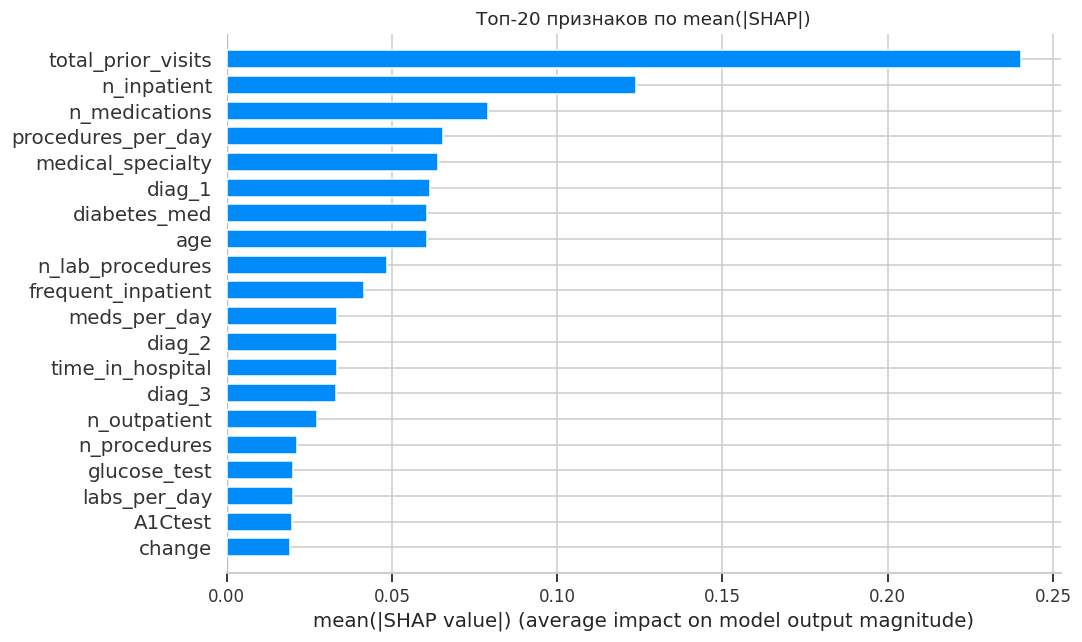

In [21]:
shap.summary_plot(shap_values, X_shap, plot_type='bar', show=False, max_display=20, plot_size=(10, 6))
plt.title('Топ-20 признаков по mean(|SHAP|)')
plt.tight_layout()
plt.show()


In [ ]:
probas_shap = catboost_model.predict_proba(X_shap)[:, 1]
low_idx, high_idx = int(np.argmin(probas_shap)), int(np.argmax(probas_shap))

expected_value = explainer.expected_value
if isinstance(expected_value, (list, np.ndarray)) and np.ndim(expected_value) > 0:
    expected_value = float(np.asarray(expected_value).ravel()[0])

base_values = np.full(shap_values.shape[0], expected_value)
explanation = shap.Explanation(values=shap_values, base_values=base_values,
                               data=X_shap.values, feature_names=list(X_shap.columns))

for local_idx, label in ((low_idx, 'Низкий риск'), (high_idx, 'Высокий риск')):
    shap.plots.waterfall(explanation[local_idx], show=False, max_display=12)
    plt.title(f'{label}: p = {probas_shap[local_idx]:.3f}')
    plt.tight_layout()
    plt.show()


## Итоговое сравнение моделей на test




In [ ]:
def f1_at(y_true, y_proba, thr):
    return float(f1_score(y_true, (y_proba >= thr).astype(int)))

summary_rows = []
for name, (y_v, p_v) in results_val.items():
    thr = thresholds[name]
    y_t, p_t = results_test[name]
    summary_rows.append({
        'модель': name,
        'ROC-AUC': roc_auc_score(y_t, p_t),
        'PR-AUC': average_precision_score(y_t, p_t),
        'F1@0.5': f1_score(y_t, (p_t >= 0.5).astype(int)),
        'F1@opt': f1_at(y_t, p_t, thr),
        'Brier': brier_score_loss(y_t, p_t),
    })
summary_rows.append({
    'модель': 'catboost_isotonic',
    'ROC-AUC': roc_auc_score(y_test, y_proba_cb_test_cal),
    'PR-AUC': average_precision_score(y_test, y_proba_cb_test_cal),
    'F1@0.5': f1_score(y_test, (y_proba_cb_test_cal >= 0.5).astype(int)),
    'F1@opt': f1_at(y_test, y_proba_cb_test_cal, thresholds['catboost']),
    'Brier': brier_score_loss(y_test, y_proba_cb_test_cal),
})

summary_df = pd.DataFrame(summary_rows).set_index('модель').round(4)
summary_df


In [ ]:
plot_roc_pr_side_by_side(results_test, 'Сравнение пяти моделей на test')
